# 17: Common Pitfalls, Diagnostics, and Reporting

DoubleML is powerful because it separates a causal target from nuisance prediction. That separation is also where many applied analyses go wrong. A DoubleML estimate becomes credible through design, overlap, nuisance diagnostics, sensitivity checks, and clear reporting. The estimate is credible only when the identification story, score construction, sample splitting, nuisance quality, and reporting all agree with each other.

The core partially linear regression design used throughout this lesson is:

$$
Y_i = \theta_0 D_i + g_0(X_i) + \varepsilon_i,
$$

$$
D_i = m_0(X_i) + V_i,
$$

with the causal target $\theta_0$. DoubleML estimates $g_0$ and $m_0$ with machine learning, residualizes both outcome and treatment, and solves an orthogonal score. For the partialling-out score, define:

$$
\hat{u}_i = Y_i - \hat{\ell}(X_i),
\qquad
\hat{v}_i = D_i - \hat{m}(X_i),
$$

where $\hat{\ell}(X_i)$ predicts $Y_i$ and $\hat{m}(X_i)$ predicts $D_i$. The score is:

$$
\psi_i(\theta) = \hat{v}_i\left(\hat{u}_i - \theta \hat{v}_i\right),
$$

and the fitted coefficient solves:

$$
\frac{1}{n}\sum_{i=1}^{n}\psi_i(\hat{\theta}) = 0.
$$

The important practical lesson is that orthogonality protects the final estimate from small nuisance errors, not from a broken design. If a confounder is missing, if a post-treatment variable is included as a control, if treatment has almost no residual variation, or if sample splitting is unstable, DoubleML will still produce a number. We work through how to detect and report those risks.

The lesson covers six applied failure modes:

- Omitted confounding that cannot be fixed by flexible learners.
- Bad controls and leakage, especially post-treatment variables.
- Weak residual treatment variation, the continuous-treatment version of poor overlap.
- Nuisance-model diagnostics that should be read as numerical checks, not causal proof.
- Sample-split sensitivity and repeated fitting.
- Reporting standards that make a DoubleML analysis auditable.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Common Pitfalls, Diagnostics, And Reporting**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the lesson separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The examples are failure cases by design. They are included so readers learn how plausible causal workflows break in practice. The examples connect diagnostics to reporting. A good report states what the data can support and where the design remains vulnerable.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Advanced DoubleML workflows still revolve around orthogonal scores. A custom score is valid only when

$$
\mathbb{E}\{\psi(W;\theta_0,\eta_0)\}=0, \qquad
\left.\partial_{\eta}\mathbb{E}\{\psi(W;\theta_0,\eta)\}\right|_{\eta=\eta_0}=0.
$$

Every estimate should be connected back to its score, nuisance functions, sample splitting, and identifying assumptions.





## Tutorial Workflow

#### Setup

This setup block imports the libraries, creates tutorial output folders, and sets a writable Matplotlib cache directory before importing plotting libraries. That small environment step keeps execution clean on machines where the default Matplotlib config directory is not writable.


In [ ]:
from pathlib import Path
import os
import warnings
# Locate the repository root even when nbconvert executes from this lesson's directory.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate pyproject.toml; run this lesson from inside the repository.")
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MPLCONFIG_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MPLCONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)
# These filters are set before importing DoubleML because some optional notebook-widget
# warnings can be emitted during import in lightweight local environments.
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
import doubleml as dml
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
sns.set_theme(style="whitegrid", context="talk")
RANDOM_SEED = 1717
NOTEBOOK_PREFIX = "17"
TRUE_THETA = 1.0
print(f"DoubleML version: {dml.__version__}")


The setup confirms that the lesson can import DoubleML and write outputs into the tutorial output folders. All files created here use prefix `17` so they are easy to connect back to this lesson.


#### Helper Functions

The helper functions keep the rest of the lesson readable. The most important helper is `fit_plr()`, which fits a `DoubleMLPLR` model and returns both the fitted object and a compact diagnostic row. The diagnostics combine causal and numerical information: coefficient error, confidence interval, nuisance RMSE, residual treatment variation, and the average score denominator.


In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, filename):
    """
    Save a table into the DoubleML tutorial table folder.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    filename : object
        Filename used when saving a table, dataset, or figure.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path
def save_dataset(df, filename):
    """
    Save a dataset into the DoubleML tutorial dataset folder.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    filename : object
        Filename used when saving a table, dataset, or figure.
    
    Returns
    -------
    pd.DataFrame
        Same dataset after writing it to the tutorial dataset directory.
    """
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path
def rmse(y_true, y_pred):
    """
    Compute root mean squared error with explicit float output.
    
    Parameters
    ----------
    y_true : array-like
        Reference or oracle values used for evaluation.
    y_pred : array-like
        Predicted or estimated values being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def extract_prediction(model, learner_name):
    """
    DoubleML stores predictions as n_obs x n_rep x n_treat arrays for this PLR setup.
    
    Parameters
    ----------
    model : object
        Fitted model or estimator being inspected.
    learner_name : str
        Readable name for the learner configuration.
    
    Returns
    -------
    np.ndarray
        Flattened prediction vector extracted from stored DoubleML nuisance predictions.
    """
    return model.predictions[learner_name][:, 0, 0]
def fit_plr(df, x_cols, learner_l, learner_m, label, true_theta=TRUE_THETA, sample_splits=None):
    """
    Fit a PLR model and return the fitted model plus a one-row diagnostic dictionary.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame used by the helper.
    x_cols : list[str]
        Covariate column names used as model inputs.
    learner_l : object
        Outcome learner used as a nuisance model.
    learner_m : object
        Treatment or propensity learner used as a nuisance model.
    label : str
        Readable label attached to the method, scenario, or output row.
    true_theta : float
        Oracle treatment-effect value used as a synthetic benchmark.
    sample_splits : list
        Fold assignments used to keep nuisance fitting separate from score evaluation.
    
    Returns
    -------
    DoubleMLPLR or tuple
        Fitted PLR model, sometimes paired with a compact summary row.
    """
    data = dml.DoubleMLData(df, y_col="outcome", d_cols="treatment", x_cols=x_cols)
    model = dml.DoubleMLPLR(
        data,
        ml_l=clone(learner_l),
        ml_m=clone(learner_m),
        n_folds=5,
        score="partialling out",
    )
    if sample_splits is not None:
        model.set_sample_splitting(sample_splits)
    model.fit(store_predictions=True)
    y_hat = extract_prediction(model, "ml_l")
    d_hat = extract_prediction(model, "ml_m")
    residualized_treatment = df["treatment"].to_numpy() - d_hat
    psi_a = model.psi_elements["psi_a"].reshape(-1)
    coef = float(model.coef[0])
    se = float(model.se[0])
    row = {
        "model": label,
        "n_controls": len(x_cols),
        "estimate": coef,
        "std_error": se,
        "ci_95_lower": coef - 1.96 * se,
        "ci_95_upper": coef + 1.96 * se,
        "true_theta": true_theta,
        "absolute_error": abs(coef - true_theta),
        "outcome_rmse": rmse(df["outcome"], y_hat),
        "treatment_rmse": rmse(df["treatment"], d_hat),
        "resid_treatment_sd": float(np.std(residualized_treatment)),
        "mean_resid_treatment_sq": float(np.mean(residualized_treatment**2)),
        "score_denominator": float(-np.mean(psi_a)),
    }
    return model, row
def make_kfold_splits(n_obs, seed, n_splits=5):
    """
    Create a DoubleML-compatible one-repetition list of train/test folds.
    
    Parameters
    ----------
    n_obs : int
        Number of observations generated for the experiment.
    seed : int
        Random seed for reproducible simulation or resampling.
    n_splits : int
        Number of `splits` used by `make_kfold_splits`.
    
    Returns
    -------
    list[tuple[np.ndarray, np.ndarray]]
        Train-test fold index pairs for cross-fitting.
    """
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return [(train_idx, test_idx) for train_idx, test_idx in kfold.split(np.arange(n_obs))]


The helper output will let us compare scenarios without hiding the mechanics. When a later table shows a bad estimate, the same row also shows whether nuisance prediction, residual treatment variation, or the control set changed.





## Reporting and Takeaways

### Pitfall Map

Before running code, it helps to name the failure modes. DoubleML is an estimator, not an identification oracle. The table below separates problems that come from the causal design from problems that come from implementation or reporting.


| pitfall | where_it_enters | symptom | recommended_check |
| --- | --- | --- | --- |
| Omitted confounding | Identification | Estimate changes sharply when an important pre-treatment confounder is added or removed. | State the adjustment set and run negative-control or sensitivity checks when possible. |
| Bad controls or leakage | Feature design | Including post-treatment variables can shrink, reverse, or otherwise distort the causal estimate. | Classify every feature by time: pre-treatment, treatment, mediator, outcome, or future signal. |
| Weak residual treatment variation | Overlap or positivity | The residualized treatment has very small variance and standard errors inflate. | Inspect residualized-treatment distributions and the score denominator. |
| Poor nuisance models | Estimation | Nuisance RMSE is high or unstable across learners and folds. | Compare learners, tune deliberately, and report nuisance diagnostics. |
| Sample-split luck | Cross-fitting | Estimates move materially across random fold assignments. | Use repeated cross-fitting or rerun over several deterministic seeds. |
| Under-reporting | Communication | Readers cannot tell what data, learners, score, folds, or assumptions produced the estimate. | Publish a compact design table, diagnostics table, and limitation statement. |


The map is the checklist for the rest of the lesson. The examples below do not try to exhaust every possible failure. They show the kinds of evidence a careful analyst should collect before trusting a DoubleML result.




### Simulate a Known-Truth Confounding Design

The first simulation makes confounding visible. The column `latent_need` acts like a strong pre-treatment confounder. We include it in the dataset so we can demonstrate what happens when it is included, omitted, or replaced with a bad post-treatment feature. In a real observational dataset, the dangerous version is worse: the confounder may be absent entirely.

The data-generating process is linear so that a well-specified baseline has a fair chance to recover the true value:

$$
D_i = h_D(X_i, U_i) + V_i,
$$

$$
Y_i = \theta_0 D_i + h_Y(X_i, U_i) + \varepsilon_i,
$$

where $U_i$ is represented by `latent_need` for learning purposes. The true effect is $\theta_0 = 1.0$.


In [3]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 1_800
n_features = 8
feature_cols = [f"x{j:02d}" for j in range(n_features)]
X = rng.normal(size=(n_obs, n_features))
latent_need = 0.8 * X[:, 0] - 0.5 * X[:, 2] + rng.normal(size=n_obs)
treatment_signal = 0.8 * X[:, 0] - 0.6 * X[:, 1] + 0.7 * X[:, 3] + 0.9 * latent_need
treatment = treatment_signal + rng.normal(scale=1.0, size=n_obs)
outcome_signal = 0.7 * X[:, 0] + 0.5 * X[:, 2] - 0.4 * X[:, 4] + 1.3 * latent_need
outcome = TRUE_THETA * treatment + outcome_signal + rng.normal(scale=1.0, size=n_obs)
# This is invalid by construction because it is built from the realized outcome and treatment.
post_outcome_proxy = 0.65 * outcome + 0.25 * treatment + rng.normal(scale=0.6, size=n_obs)
confounding_df = pd.DataFrame(X, columns=feature_cols)
confounding_df["latent_need"] = latent_need
confounding_df["post_outcome_proxy"] = post_outcome_proxy
confounding_df["treatment"] = treatment
confounding_df["outcome"] = outcome
save_dataset(confounding_df, f"{NOTEBOOK_PREFIX}_confounding_pitfall_data.csv")
confounding_df.head()


,x00,x01,x02,x03,x04,x05,x06,x07,latent_need,post_outcome_proxy,treatment,outcome
0,-0.442486,-1.011796,1.201736,2.003726,-1.765337,0.989969,-0.073723,0.550082,-1.794301,-0.766049,0.959050,-0.799115
1,0.554699,1.422543,2.628656,0.815418,-0.014838,-1.169905,-0.249729,0.077894,-0.993645,-2.153806,-1.056584,-1.598617
2,-0.366996,-0.303584,-0.234200,0.274319,0.254770,0.347296,-0.393850,0.151550,0.585688,1.512251,0.909832,2.748031
3,0.286510,-0.129636,-0.545928,1.210361,1.064770,-1.940194,0.587672,-1.605602,1.530225,5.508370,4.771020,6.434808
4,-0.104771,-0.211868,0.117987,-0.021909,0.121693,-1.511996,-1.307896,0.595820,-0.064173,-0.275525,0.830392,-0.186563


The first rows show ordinary pre-treatment controls, the teaching confounder `latent_need`, the invalid `post_outcome_proxy`, the treatment, and the outcome. The next step is to document these fields so the control-set choices are explicit instead of hidden inside model code.


### Field Dictionary

Feature timing is one of the most important reporting details in causal work. A variable can be predictive and still be invalid as a control. The table below classifies each group of columns by causal role.


| field_group | role | safe_for_adjustment | notes |
| --- | --- | --- | --- |
| x00 to x07 | Observed pre-treatment controls | Yes | Baseline covariates measured before treatment assignment. |
| latent_need | Strong pre-treatment confounder used for learning | Yes, if it is genuinely observed before treatment | Omitting it creates a controlled demonstration of unmeasured-confounding bias. |
| post_outcome_proxy | Post-treatment leakage variable | No | It is partly constructed from outcome and treatment, so adjusting for it changes the causal question. |
| treatment | Continuous treatment D | Target treatment, not a control | The effect of this variable on outcome is the target of estimation. |
| outcome | Outcome Y | No | This is the response variable, not a feature for the nuisance models. |


The dictionary makes the coming scenarios easier to judge. Including `latent_need` is valid in this example dataset because it is pre-treatment. Including `post_outcome_proxy` is not valid even though it will be highly predictive.


### Design Diagram

The diagram summarizes the first simulation. Solid arrows show the intended causal and confounding structure. The dashed arrow marks the bad-control path created when a post-treatment proxy is included as if it were a baseline covariate.


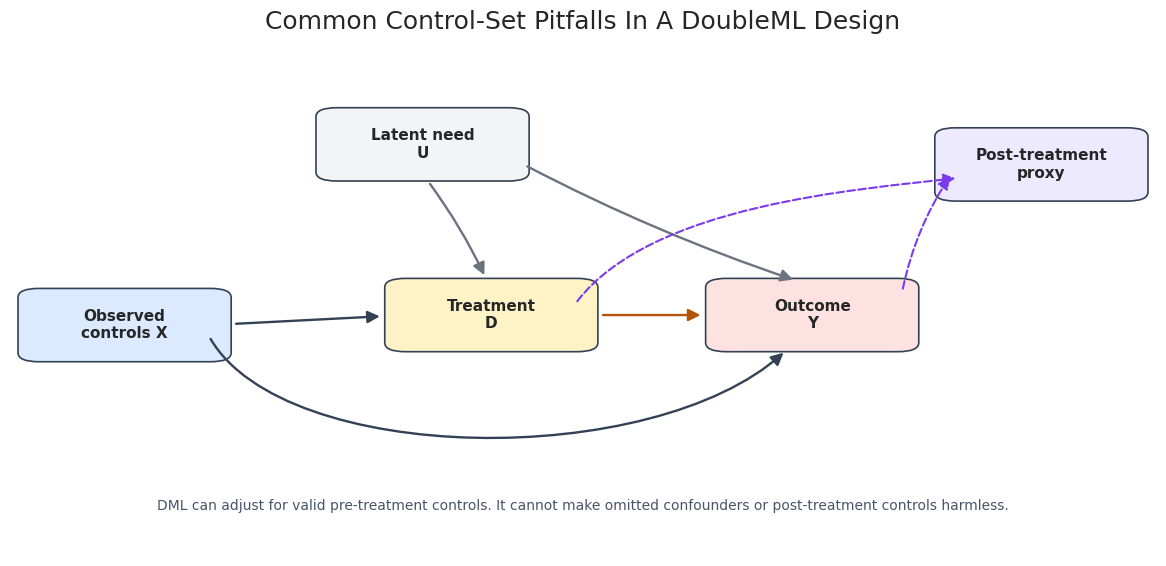

In [4]:
# Define reusable helpers for the Design Diagram section.
from matplotlib.path import Path as MplPath
nodes = {
    "X": {"xy": (0.10, 0.46), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "U": {"xy": (0.36, 0.82), "label": "Latent need\nU", "color": "#f3f4f6"},
    "D": {"xy": (0.42, 0.48), "label": "Treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.70, 0.48), "label": "Outcome\nY", "color": "#fee2e2"},
    "P": {"xy": (0.90, 0.78), "label": "Post-treatment\nproxy", "color": "#ede9fe"},
}
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()
box_w, box_h = 0.15, 0.11
def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)
def shorten(start, end, gap=0.020):
    """
    Idea: Shorten a line segment so the arrowhead remains visible outside the node box.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[float, float]
        Shortened endpoint coordinate that keeps an arrowhead visible.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)
def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
        clip_on=False,
    )
    ax.add_patch(arrow)
def draw_bezier_arrow(start, control_1, control_2, end, color="#334155", style="solid", linewidth=1.7):
    # Use one continuous cubic Bezier path so routed arrows never appear broken.
    """
    Idea: Draw a curved arrow for a flowchart or graph diagram.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    control_1 : object
        First control variable used in the adjustment example.
    control_2 : object
        Second control variable used in the adjustment example.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds a curved arrow annotation directly to the supplied Matplotlib axes.
    """
    vertices = [tuple(start), tuple(control_1), tuple(control_2), tuple(end)]
    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4]
    path = MplPath(vertices, codes)
    arrow = FancyArrowPatch(
        path=path,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        zorder=5,
        clip_on=False,
    )
    ax.add_patch(arrow)
# Draw arrows before boxes so node labels stay readable, but keep every arrow as one continuous patch.
draw_arrow(anchor("X", "right"), anchor("D", "left"), color="#334155")
draw_bezier_arrow(
    anchor("X", "lower_right"),
    np.array([0.24, 0.18]),
    np.array([0.56, 0.17]),
    anchor("Y", "bottom") + np.array([-0.025, -0.020]),
    color="#334155",
)
draw_arrow(anchor("U", "bottom"), anchor("D", "top"), color="#6b7280", rad=-0.05)
draw_arrow(anchor("U", "lower_right"), anchor("Y", "top"), color="#6b7280", rad=0.04)
draw_arrow(anchor("D", "right"), anchor("Y", "left"), color="#b45309")
draw_arrow(anchor("Y", "upper_right"), anchor("P", "left"), color="#7c3aed", style="dashed", rad=-0.10, linewidth=1.5)
draw_bezier_arrow(
    anchor("D", "upper_right"),
    np.array([0.56, 0.70]),
    np.array([0.74, 0.73]),
    anchor("P", "lower_left"),
    color="#7c3aed",
    style="dashed",
    linewidth=1.5,
)
for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)
ax.text(
    0.50,
    0.10,
    "DML can adjust for valid pre-treatment controls. It cannot make omitted confounders or post-treatment controls harmless.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Common Control-Set Pitfalls In A DoubleML Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_control_set_pitfall_dag.png", dpi=160, bbox_inches="tight")
plt.show()


The diagram is a compact reminder of the control-set rule. Valid controls are measured before treatment and help block backdoor paths. A post-treatment proxy is not made valid by being predictive.


### Fit Control-Set Scenarios

Now we fit four versions of the same PLR analysis. The only thing that changes is the feature set. This isolates a central lesson: DoubleML can only adjust for the variables we give it, and giving it the wrong variables can be worse than giving it too few.


In [5]:
linear_learner = LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=10_000)
control_sets = {
    "Valid controls including latent_need": feature_cols + ["latent_need"],
    "Omitted latent_need": feature_cols,
    "Too few controls": ["x00", "x01"],
    "Bad post-treatment control": feature_cols + ["latent_need", "post_outcome_proxy"],
}
control_models = {}
control_rows = []
for label, x_cols in control_sets.items():
    model, row = fit_plr(
        confounding_df,
        x_cols=x_cols,
        learner_l=linear_learner,
        learner_m=linear_learner,
        label=label,
    )
    control_models[label] = model
    control_rows.append(row)
control_results = pd.DataFrame(control_rows).sort_values("absolute_error")
save_table(control_results, f"{NOTEBOOK_PREFIX}_control_set_scenarios.csv")
display(control_results)


,model,n_controls,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error,outcome_rmse,treatment_rmse,resid_treatment_sd,mean_resid_treatment_sq,score_denominator
0,Valid controls including latent_need,9,1.014014,0.024004,0.966966,1.061061,1.0,0.014014,1.451997,1.011065,1.011064,1.022253,1.022253
2,Too few controls,2,1.512930,0.021892,1.470022,1.555838,1.0,0.512930,2.871991,1.601039,1.601038,2.563326,2.563326
1,Omitted latent_need,8,1.668246,0.024382,1.620456,1.716036,1.0,0.668246,2.685938,1.363769,1.363768,1.859866,1.859866
3,Bad post-treatment control,10,0.252987,0.022342,0.209197,0.296776,1.0,0.747013,0.715280,0.710615,0.710615,0.504974,0.504974


The valid-control model is closest to the known truth. Omitting the strong confounder pushes the estimate upward, while adding a post-treatment proxy severely distorts the answer. The table is deliberately blunt: accurate prediction and valid adjustment are different goals.


#### Plot Control-Set Estimates

A plot makes the control-set risk easier to scan. The vertical line marks the true effect used by the simulator, and each interval is a normal 95% confidence interval from the fitted DoubleML model.


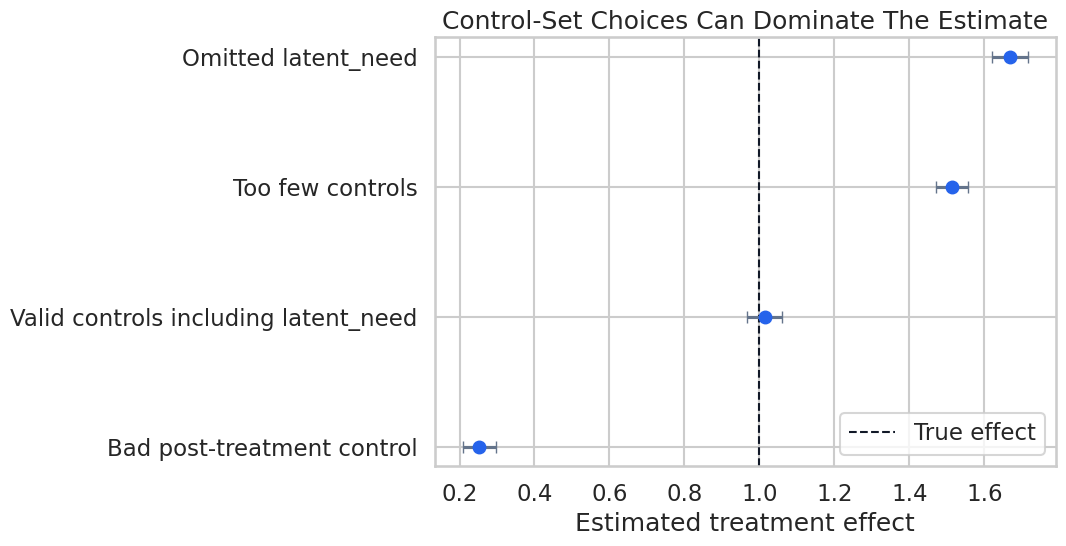

In [6]:
plot_df = control_results.sort_values("estimate").copy()
plot_df["lower_error"] = plot_df["estimate"] - plot_df["ci_95_lower"]
plot_df["upper_error"] = plot_df["ci_95_upper"] - plot_df["estimate"]
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.axvline(TRUE_THETA, color="#111827", linestyle="--", linewidth=1.5, label="True effect")
ax.errorbar(
    x=plot_df["estimate"],
    y=np.arange(len(plot_df)),
    xerr=[plot_df["lower_error"], plot_df["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["model"])
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.set_title("Control-Set Choices Can Dominate The Estimate")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_control_set_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


The visual gap between scenarios is the main lesson. A narrow interval around a biased estimate is still a bad causal result. Reporting only one preferred specification would hide the fragility created by the control set.




#### Residual and Nuisance Diagnostics

DoubleML estimates rely on nuisance models, but nuisance diagnostics should be read carefully. Low RMSE is useful; it is not proof that the adjustment set is valid. The code below compares nuisance prediction quality and residualized-treatment variation across the control-set scenarios.


In [7]:
diagnostic_cols = [
    "model",
    "outcome_rmse",
    "treatment_rmse",
    "resid_treatment_sd",
    "mean_resid_treatment_sq",
    "score_denominator",
    "absolute_error",
]
control_diagnostics = control_results[diagnostic_cols].sort_values("absolute_error")
save_table(control_diagnostics, f"{NOTEBOOK_PREFIX}_control_set_diagnostics.csv")
display(control_diagnostics)


,model,outcome_rmse,treatment_rmse,resid_treatment_sd,mean_resid_treatment_sq,score_denominator,absolute_error
0,Valid controls including latent_need,1.451997,1.011065,1.011064,1.022253,1.022253,0.014014
2,Too few controls,2.871991,1.601039,1.601038,2.563326,2.563326,0.512930
1,Omitted latent_need,2.685938,1.363769,1.363768,1.859866,1.859866,0.668246
3,Bad post-treatment control,0.715280,0.710615,0.710615,0.504974,0.504974,0.747013


The bad post-treatment control can look numerically attractive because it predicts outcome-related variation. That is exactly why timing metadata matters. A diagnostic can tell us how a learner behaved; it cannot decide whether a feature belongs in the causal design.




#### Weak Residual Treatment Variation

For a continuous treatment, overlap shows up as residual treatment variation after adjusting for controls. If the treatment is almost deterministic given the controls, then $\hat{v}_i = D_i - \hat{m}(X_i)$ is tiny. The score denominator becomes small, and the estimate can become noisy.

This simulation changes only the treatment-noise scale. Smaller treatment noise means weaker residual variation.


In [8]:
# Define reusable helpers for the Weak Residual Treatment Variation section.
def make_overlap_data(treatment_noise_sd, seed):
    """
    Idea: Construct the overlap data used in the Weak Residual Treatment Variation section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    treatment_noise_sd : object
        Noise level in the treatment assignment mechanism.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame or dict
        Named df object assembled by make overlap data.
    """
    rng = np.random.default_rng(seed)
    n_obs = 1_600
    n_features = 8
    X = rng.normal(size=(n_obs, n_features))
    latent_need = 0.8 * X[:, 0] - 0.5 * X[:, 2] + rng.normal(size=n_obs)
    treatment_signal = 0.8 * X[:, 0] - 0.6 * X[:, 1] + 0.7 * X[:, 3] + 0.9 * latent_need
    treatment = treatment_signal + rng.normal(scale=treatment_noise_sd, size=n_obs)
    outcome_signal = 0.7 * X[:, 0] + 0.5 * X[:, 2] - 0.4 * X[:, 4] + 1.3 * latent_need
    outcome = TRUE_THETA * treatment + outcome_signal + rng.normal(scale=1.0, size=n_obs)
    df = pd.DataFrame(X, columns=feature_cols)
    df["latent_need"] = latent_need
    df["treatment"] = treatment
    df["outcome"] = outcome
    return df
noise_levels = [1.00, 0.35, 0.15]
overlap_rows = []
overlap_models = {}
for noise_sd in noise_levels:
    overlap_df = make_overlap_data(treatment_noise_sd=noise_sd, seed=RANDOM_SEED + int(noise_sd * 1000))
    label = f"Treatment noise sd = {noise_sd:.2f}"
    model, row = fit_plr(
        overlap_df,
        x_cols=feature_cols + ["latent_need"],
        learner_l=linear_learner,
        learner_m=linear_learner,
        label=label,
    )
    row["treatment_noise_sd"] = noise_sd
    overlap_rows.append(row)
    overlap_models[label] = (model, overlap_df)
overlap_results = pd.DataFrame(overlap_rows).sort_values("treatment_noise_sd", ascending=False)
save_table(overlap_results, f"{NOTEBOOK_PREFIX}_residual_treatment_variation.csv")
display(overlap_results[["model", "estimate", "std_error", "resid_treatment_sd", "mean_resid_treatment_sq", "score_denominator", "absolute_error"]])


,model,estimate,std_error,resid_treatment_sd,mean_resid_treatment_sq,score_denominator,absolute_error
0,Treatment noise sd = 1.00,0.980986,0.027096,0.984570,0.969379,0.969379,0.019014
1,Treatment noise sd = 0.35,1.198619,0.070299,0.342982,0.117637,0.117637,0.198619
2,Treatment noise sd = 0.15,0.936494,0.147688,0.152868,0.023369,0.023369,0.063506


As residual treatment variation gets smaller, the standard error grows and the estimate becomes more fragile. This is not a learner failure; it is a design problem. There is not enough treatment movement left after adjustment to estimate the slope precisely.


#### Plot Residual Treatment Variation

The next plot shows the distribution of residualized treatment for each noise level. This is the continuous-treatment diagnostic behind the previous table.


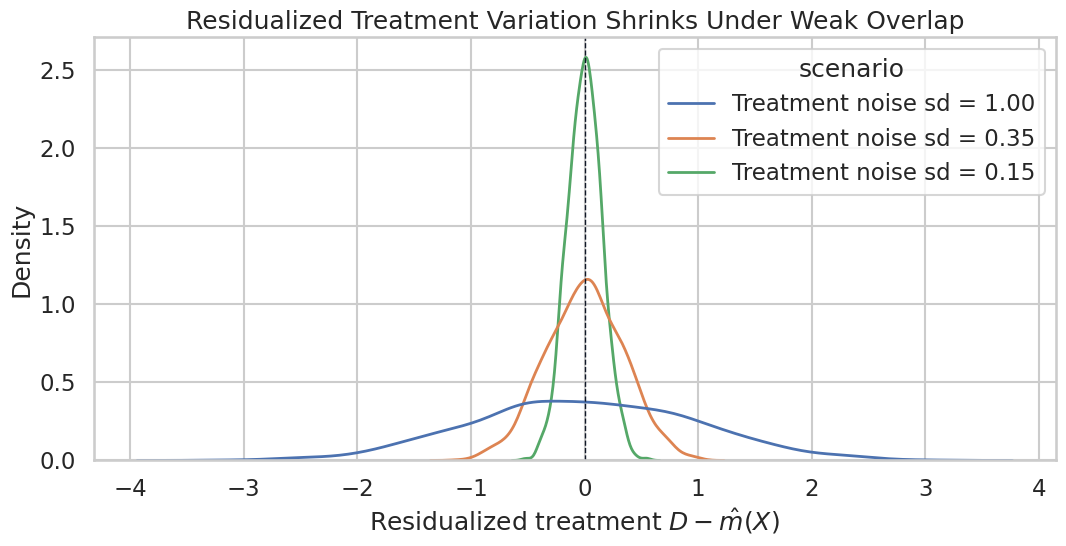

In [9]:
# Build and label the diagnostic visualization for the Plot Residual Treatment Variation section.
residual_plot_frames = []
for label, (model, df) in overlap_models.items():
    d_hat = extract_prediction(model, "ml_m")
    residual_plot_frames.append(
        pd.DataFrame(
            {
                "scenario": label,
                "residualized_treatment": df["treatment"].to_numpy() - d_hat,
            }
        )
    )
residual_plot_df = pd.concat(residual_plot_frames, ignore_index=True)
fig, ax = plt.subplots(figsize=(11, 5.8))
sns.kdeplot(
    data=residual_plot_df,
    x="residualized_treatment",
    hue="scenario",
    common_norm=False,
    linewidth=2,
    ax=ax,
)
ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Residualized Treatment Variation Shrinks Under Weak Overlap")
ax.set_xlabel(r"Residualized treatment $D - \hat{m}(X)$")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residualized_treatment_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The narrowest curve corresponds to the weakest residual variation. A DoubleML report should include this kind of diagnostic when the treatment is continuous or when treatment assignment is highly predictable from controls.




#### Nuisance Learner Comparison

The next simulation is nonlinear. We compare nuisance learners without mistaking predictive performance for identification, using a simple linear learner and a random forest on the same known-truth design.


In [10]:
# Define reusable helpers for the Nuisance Learner Comparison section.
def make_nonlinear_data(seed):
    """
    Idea: Construct the nonlinear data used in the Nuisance Learner Comparison section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    pd.DataFrame or dict
        Named df object assembled by make nonlinear data.
    """
    rng = np.random.default_rng(seed)
    n_obs = 1_600
    X = rng.normal(size=(n_obs, len(feature_cols)))
    m0 = 1.1 * np.sin(X[:, 0]) + 0.7 * X[:, 1] * X[:, 2] - 0.6 * (X[:, 3] > 0) + 0.3 * X[:, 4] ** 2
    treatment = m0 + rng.normal(scale=1.0, size=n_obs)
    g0 = 0.9 * np.cos(X[:, 0]) + 0.8 * X[:, 2] ** 2 - 0.4 * X[:, 5] * X[:, 6]
    outcome = TRUE_THETA * treatment + g0 + rng.normal(scale=1.0, size=n_obs)
    df = pd.DataFrame(X, columns=feature_cols)
    df["treatment"] = treatment
    df["outcome"] = outcome
    return df
nonlinear_df = make_nonlinear_data(RANDOM_SEED + 404)
save_dataset(nonlinear_df, f"{NOTEBOOK_PREFIX}_nonlinear_nuisance_data.csv")
learner_specs = {
    "Linear regression": LinearRegression(),
    "Random forest": RandomForestRegressor(
        n_estimators=220,
        min_samples_leaf=8,
        max_features="sqrt",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}
learner_rows = []
learner_models = {}
for label, learner in learner_specs.items():
    model, row = fit_plr(
        nonlinear_df,
        x_cols=feature_cols,
        learner_l=learner,
        learner_m=learner,
        label=label,
    )
    learner_rows.append(row)
    learner_models[label] = model
learner_results = pd.DataFrame(learner_rows).sort_values("outcome_rmse")
save_table(learner_results, f"{NOTEBOOK_PREFIX}_nuisance_learner_comparison.csv")
display(learner_results[["model", "estimate", "std_error", "absolute_error", "outcome_rmse", "treatment_rmse", "resid_treatment_sd"]])


,model,estimate,std_error,absolute_error,outcome_rmse,treatment_rmse,resid_treatment_sd
1,Random forest,0.951026,0.027596,0.048974,1.640721,1.190422,1.190419
0,Linear regression,0.936522,0.034555,0.063478,1.944309,1.288490,1.288490


The random forest improves nuisance prediction in this nonlinear design. The causal estimate is still judged against the known truth, not against RMSE alone. Since the true effect is unknown in real data, this table becomes evidence about numerical plausibility and stability.


#### Plot Learner Diagnostics

This plot puts the nuisance-model comparison into one view: treatment-effect error on one axis and nuisance RMSE on the other. It is a compact way to discuss whether better nuisance prediction also produced a more stable target estimate.


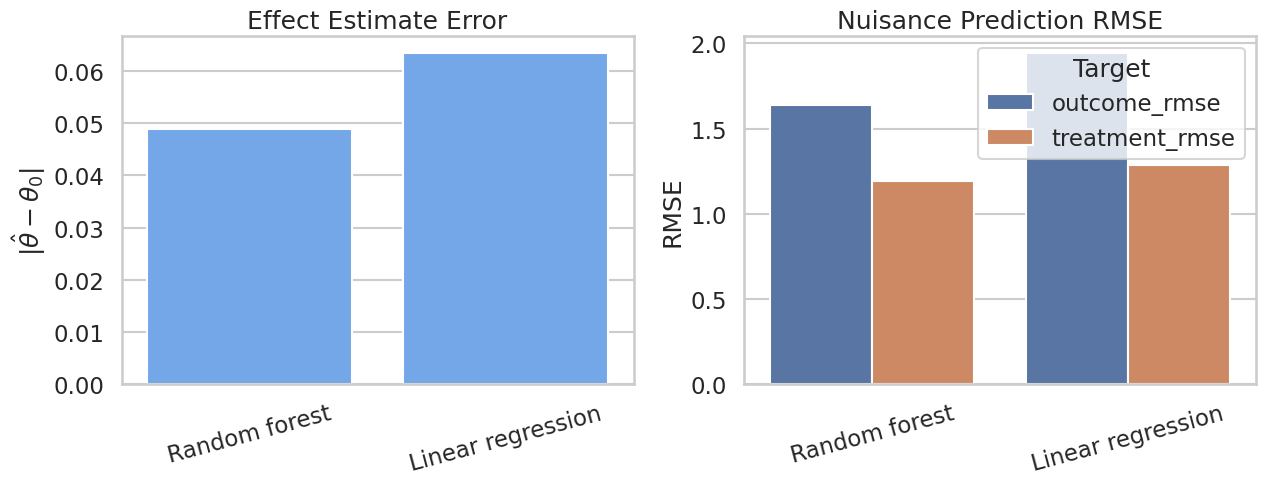

In [11]:
# Build and label the diagnostic visualization for the Plot Learner Diagnostics section.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.barplot(
    data=learner_results,
    x="model",
    y="absolute_error",
    color="#60a5fa",
    ax=axes[0],
)
axes[0].set_title("Effect Estimate Error")
axes[0].set_xlabel("")
axes[0].set_ylabel(r"$|\hat{\theta} - \theta_0|$")
axes[0].tick_params(axis="x", rotation=15)
nuisance_long = learner_results.melt(
    id_vars="model",
    value_vars=["outcome_rmse", "treatment_rmse"],
    var_name="nuisance_target",
    value_name="rmse",
)
sns.barplot(
    data=nuisance_long,
    x="model",
    y="rmse",
    hue="nuisance_target",
    ax=axes[1],
)
axes[1].set_title("Nuisance Prediction RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Target", loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_learner_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


The two panels should be read together. Strong nuisance models are helpful, but the report should not claim that a lower prediction error proves the causal estimate. Prediction diagnostics support the estimation story; they do not replace the assumptions.


#### Sample-Split Sensitivity

Cross-fitting uses fold assignments. A single random split is usually not the whole story. The code below refits the same valid-control design over multiple fixed fold seeds and records how much the estimate moves.


In [12]:
split_rows = []
split_seeds = list(range(RANDOM_SEED, RANDOM_SEED + 14))
valid_x_cols = feature_cols + ["latent_need"]
for seed in split_seeds:
    sample_splits = make_kfold_splits(len(confounding_df), seed=seed, n_splits=5)
    model, row = fit_plr(
        confounding_df,
        x_cols=valid_x_cols,
        learner_l=linear_learner,
        learner_m=linear_learner,
        label=f"split_seed_{seed}",
        sample_splits=sample_splits,
    )
    row["split_seed"] = seed
    split_rows.append(row)
split_results = pd.DataFrame(split_rows)
split_summary = pd.DataFrame(
    [
        {
            "n_repetitions": len(split_results),
            "mean_estimate": split_results["estimate"].mean(),
            "sd_estimate": split_results["estimate"].std(ddof=1),
            "min_estimate": split_results["estimate"].min(),
            "max_estimate": split_results["estimate"].max(),
            "mean_std_error": split_results["std_error"].mean(),
            "true_theta": TRUE_THETA,
        }
    ]
)
save_table(split_results, f"{NOTEBOOK_PREFIX}_sample_split_repetitions.csv")
save_table(split_summary, f"{NOTEBOOK_PREFIX}_sample_split_summary.csv")
display(split_summary)


,n_repetitions,mean_estimate,sd_estimate,min_estimate,max_estimate,mean_std_error,true_theta
0,14,1.013214,0.001735,1.009349,1.016719,0.023996,1.0


The split summary tells us whether one fold assignment was unusually lucky or unlucky. In this clean simulation, the repeated estimates should be fairly stable. In noisier real applications, this can be one of the most useful robustness checks.


#### Plot Sample-Split Stability

The next plot shows each repeated estimate and the known true effect. This is a simple visual habit that makes cross-fitting randomness visible.


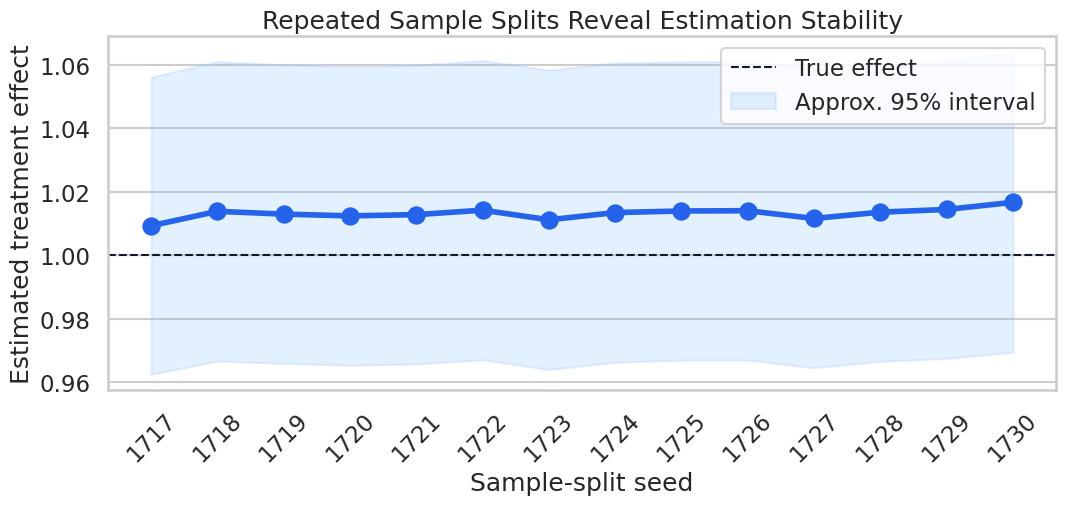

In [13]:
# Build and label the diagnostic visualization for the Plot Sample-Split Stability section.
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.axhline(TRUE_THETA, color="#111827", linestyle="--", linewidth=1.5, label="True effect")
sns.pointplot(
    data=split_results,
    x="split_seed",
    y="estimate",
    color="#2563eb",
    errorbar=None,
    ax=ax,
)
ax.fill_between(
    np.arange(len(split_results)),
    split_results.sort_values("split_seed")["estimate"] - 1.96 * split_results.sort_values("split_seed")["std_error"],
    split_results.sort_values("split_seed")["estimate"] + 1.96 * split_results.sort_values("split_seed")["std_error"],
    color="#93c5fd",
    alpha=0.25,
    label="Approx. 95% interval",
)
ax.set_title("Repeated Sample Splits Reveal Estimation Stability")
ax.set_xlabel("Sample-split seed")
ax.set_ylabel("Estimated treatment effect")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()


The estimates cluster tightly in this example. If the dots jumped across substantively different values, the report should say so and either use repeated cross-fitting or explain why the design is unstable.


#### Diagnostic Scorecard

A good DoubleML report should not bury diagnostics in scattered lesson cells. This scorecard converts the previous examples into a compact review table. The goal is to make it easy to see which risks were checked, what evidence was produced, and what remains unresolved.


In [ ]:
valid_row = control_results.loc[control_results["model"].eq("Valid controls including latent_need")].iloc[0]
omitted_row = control_results.loc[control_results["model"].eq("Omitted latent_need")].iloc[0]
bad_control_row = control_results.loc[control_results["model"].eq("Bad post-treatment control")].iloc[0]
weak_overlap_row = overlap_results.loc[overlap_results["treatment_noise_sd"].eq(0.15)].iloc[0]
scorecard = pd.DataFrame(
    [
        {
            "risk_area": "Confounding",
            "evidence_checked": f"Omitting latent_need changed estimate from {valid_row['estimate']:.3f} to {omitted_row['estimate']:.3f}.",
            "status": "Requires design justification",
            "reporting_action": "State adjustment set and discuss unavailable confounders.",
        },
        {
            "risk_area": "Bad controls",
            "evidence_checked": f"Adding post_outcome_proxy moved estimate to {bad_control_row['estimate']:.3f}.",
            "status": "High risk if included",
            "reporting_action": "Classify variables by measurement time and exclude post-treatment controls.",
        },
        {
            "risk_area": "Residual treatment variation",
            "evidence_checked": f"Weakest scenario residual SD is {weak_overlap_row['resid_treatment_sd']:.3f} with SE {weak_overlap_row['std_error']:.3f}.",
            "status": "Check required",
            "reporting_action": "Show residualized-treatment distribution or equivalent overlap diagnostic.",
        },
        {
            "risk_area": "Nuisance quality",
            "evidence_checked": "Linear and forest learners were compared on a nonlinear design.",
            "status": "Model-dependent",
            "reporting_action": "Report learner settings, nuisance RMSE, and tuning choices.",
        },
        {
            "risk_area": "Sample splitting",
            "evidence_checked": f"Repeated split SD is {split_summary.loc[0, 'sd_estimate']:.4f}.",
            "status": "Stable in this simulation",
            "reporting_action": "Report fold count, repetition count, and random seeds.",
        },
        {
            "risk_area": "Communication",
            "evidence_checked": "Tables and figures are available for review.",
            "status": "Report explicitly",
            "reporting_action": "Include assumptions, diagnostics, limitations, and decision implications.",
        },
    ]
)
save_table(scorecard, f"{NOTEBOOK_PREFIX}_diagnostic_scorecard.csv")
display(scorecard)


The scorecard is plain. A reader should be able to understand the main risks without rerunning the entire lesson. The most important unresolved item in real data is usually confounding that was not measured.


#### Plot Diagnostic Scorecard

A small heatmap-style display can help summarize which risks are resolved, checked, or still dependent on assumptions. This is not a statistical test. It is a communication device for review.


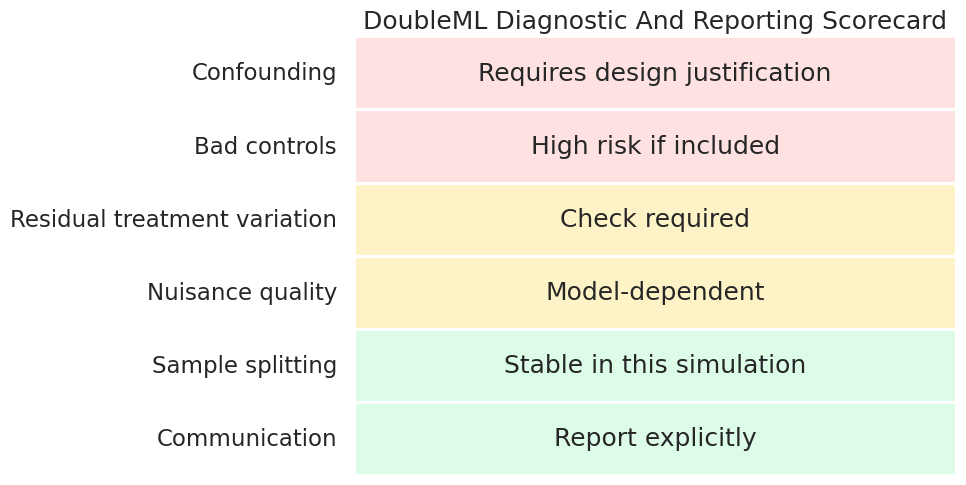

In [15]:
# Build and label the diagnostic visualization for the Plot Diagnostic Scorecard section.
status_order = {
    "Stable in this simulation": 1,
    "Report explicitly": 1,
    "Check required": 2,
    "Model-dependent": 2,
    "Requires design justification": 3,
    "High risk if included": 3,
}
scorecard_plot = scorecard.assign(risk_level=scorecard["status"].map(status_order))
fig, ax = plt.subplots(figsize=(10, 5.2))
heatmap_data = scorecard_plot.set_index("risk_area")[["risk_level"]]
sns.heatmap(
    heatmap_data,
    annot=scorecard_plot.set_index("risk_area")[["status"]],
    fmt="",
    cmap=sns.color_palette(["#dcfce7", "#fef3c7", "#fee2e2"], as_cmap=True),
    cbar=False,
    linewidths=1,
    linecolor="#ffffff",
    xticklabels=False,
    ax=ax,
)
ax.set_title("DoubleML Diagnostic And Reporting Scorecard")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", bottom=False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_diagnostic_scorecard.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap keeps the report honest: some items can be checked numerically, while others remain design assumptions. The red cells are not failures by themselves; they are places where a serious report needs careful language.


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


The template is meant to be copied forward into real analyses. It also makes the tutorial concrete: every major claim made by the lesson has a corresponding output path.


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


## What Comes Next

The sequence next moves to an end-to-end DoubleML case study. It brings together a clear causal question, correct data backend, suitable estimator class, deliberate learners, cross-fitting diagnostics, uncertainty, sensitivity analysis, pitfall checks, and a concise written conclusion.

A good DoubleML analysis starts by making the causal design explicit, then uses orthogonal scores to estimate the target effect. The estimate deserves attention when the assumptions, diagnostics, and remaining failure modes are visible.
